# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 54s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

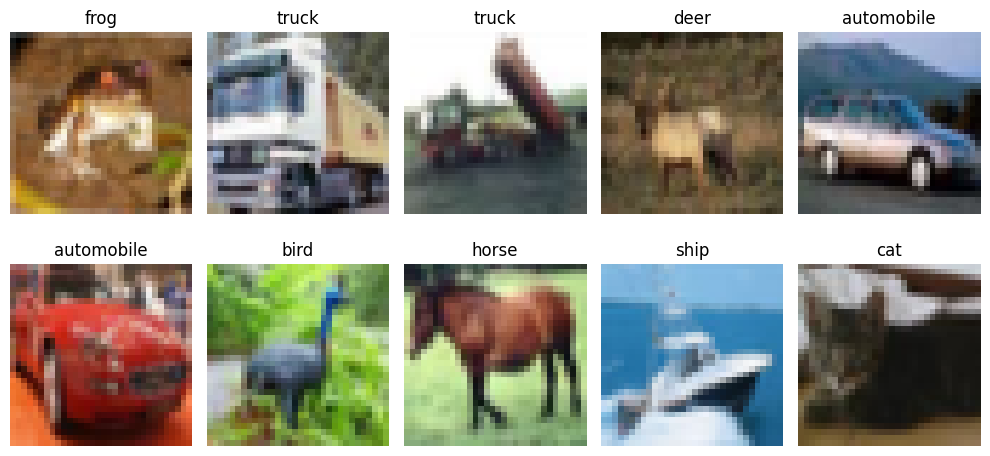

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.2659 - loss: 2.0041 - val_accuracy: 0.3230 - val_loss: 1.8905
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3135 - loss: 1.8804 - val_accuracy: 0.3614 - val_loss: 1.7993
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3335 - loss: 1.8314 - val_accuracy: 0.3592 - val_loss: 1.7825
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3489 - loss: 1.7921 - val_accuracy: 0.3652 - val_loss: 1.7538
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3579 - loss: 1.7693 - val_accuracy: 0.3966 - val_loss: 1.7081
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3641 - loss: 1.7449 - val_accuracy: 0.4020 - val_loss: 1.6907
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3702 - loss: 1.7373 - val_accuracy: 0.4172 - val_loss: 1.6733
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3792 - loss: 1.7139 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4297 - loss: 1.6216
ANN Test Accuracy: 0.42969998717308044


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 133ms/step - accuracy: 0.4647 - loss: 1.5008 - val_accuracy: 0.5596 - val_loss: 1.2228
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 128ms/step - accuracy: 0.6063 - loss: 1.1255 - val_accuracy: 0.5542 - val_loss: 1.2907
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.6699 - loss: 0.9511 - val_accuracy: 0.6306 - val_loss: 1.0831
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7123 - loss: 0.8304 - val_accuracy: 0.7044 - val_loss: 0.8660
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.7440 - loss: 0.7350 - val_accuracy: 0.7198 - val_loss: 0.8177
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.7717 - loss: 0.6515 - val_accuracy: 0.6618 - val_loss: 1.0608
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7953 - loss: 0.5836 - val_accuracy: 0.6952 - val_loss: 0.9210
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.8144 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7248 - loss: 0.9102
CNN Test Accuracy: 0.7247999906539917


## 📈 Compare Learning Curves

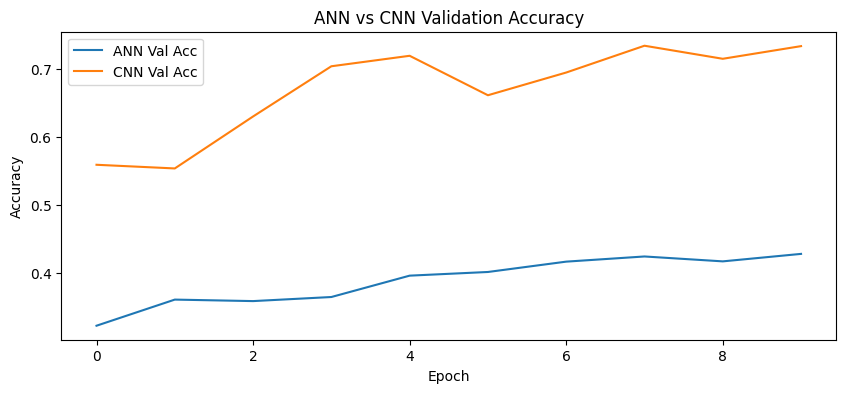

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4297
1,CNN,0.7248


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [12]:
# Task - 1
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Original ANN Test Accuracy:", ann_test_acc)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.2537 - loss: 2.0151 - val_accuracy: 0.3296 - val_loss: 1.8448
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3201 - loss: 1.8668 - val_accuracy: 0.3350 - val_loss: 1.8441
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.3418 - loss: 1.8106 - val_accuracy: 0.3738 - val_loss: 1.7657
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.3528 - loss: 1.7801 - val_accuracy: 0.3898 - val_loss: 1.7199
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.3641 - loss: 1.7510 - val_accuracy: 0.3906 - val_loss: 1.7032
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3750 - loss: 1.7275 - val_accuracy: 0.3952 - val_loss: 1.6834
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3825 - loss: 1.7156 - val_accuracy: 0.4118 - val_loss: 1.6754
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3915 - loss: 1.6889 - 

In [13]:
# Task - 2,3,4
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 212ms/step - accuracy: 0.4451 - loss: 1.5615 - val_accuracy: 0.4152 - val_loss: 1.8172
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.5925 - loss: 1.1633 - val_accuracy: 0.5770 - val_loss: 1.2036
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 208ms/step - accuracy: 0.6599 - loss: 0.9780 - val_accuracy: 0.6256 - val_loss: 1.0688
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.7011 - loss: 0.8671 - val_accuracy: 0.6012 - val_loss: 1.2612
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.7303 - loss: 0.7738 - val_accuracy: 0.6692 - val_loss: 0.9779
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 205ms/step - accuracy: 0.7562 - loss: 0.6968 - val_accuracy: 0.7630 - val_loss: 0.6935
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 209ms/step - accuracy: 0.7825 - loss: 0.6260 - val_accuracy: 0.7416 - val_loss: 0.7646
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 210ms/step - accuracy: 0.7976 -

In [14]:
# Task - 5
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

aug_early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.3620 - loss: 1.7483 - val_accuracy: 0.4634 - val_loss: 1.4834
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.4626 - loss: 1.5003 - val_accuracy: 0.5392 - val_loss: 1.2874
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.4958 - loss: 1.4084 - val_accuracy: 0.5352 - val_loss: 1.3029
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5205 - loss: 1.3461 - val_accuracy: 0.5458 - val_loss: 1.2693
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.5388 - loss: 1.2952 - val_accuracy: 0.6086 - val_loss: 1.0934
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 100ms/step - accuracy: 0.5522 - loss: 1.2663 - val_accuracy: 0.6142 - val_loss: 1.0768
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.5601 - loss: 1.2408 - val_accuracy: 0.6190 - val_loss: 1.0636
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.5716 - loss: 1.2

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**